In [4]:
#reading file 
import pandas as pd
with open('EV_sales.csv') as E:
    ev=pd.read_csv(E)
ev

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,1,2021,Andhra Pradesh,BYD,Electric Scooter,2106,30
1,2,2022,Gujarat,Tata,Electric Bike,4567,13
2,3,2025,Tamil Nadu,Tata,Electric Car,867,29
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37
...,...,...,...,...,...,...,...
145,146,2021,Andhra Pradesh,MG,Electric Scooter,706,75
146,147,2021,Telangana,Ola,Electric Bike,2589,12
147,148,2022,Andhra Pradesh,Mahindra,Electric Scooter,4983,30
148,149,2025,Tamil Nadu,MG,Electric Scooter,2535,56


### Dashboard

### Layout
# ⚡ EV SALES ANALYSIS DASHBOARD

| Total EV | Avg Sales / Entry | Avg Battery Capacity | Latest Data Year |
| :---: | :---: | :---: | :---: |
| **154,230** | **1,028.2** | **42.5 kWh** | **2025** |

---

| EV Sales Trend | Battery Distribution |
| :--- | :--- |
| *(Line Chart: 2021 - 2025)* <br><br><br><br> | *(Histogram with fine-tuned KDE line)* <br><br><br><br> |

---

| Correlation Heatmap | Sales vs Battery Capacity |
| :--- | :--- |
| *(Matrix: Relationships among numerical columns)* <br><br><br><br> | *(Scatter Plot color-coded by Vehicle Type)* <br><br><br><br> |

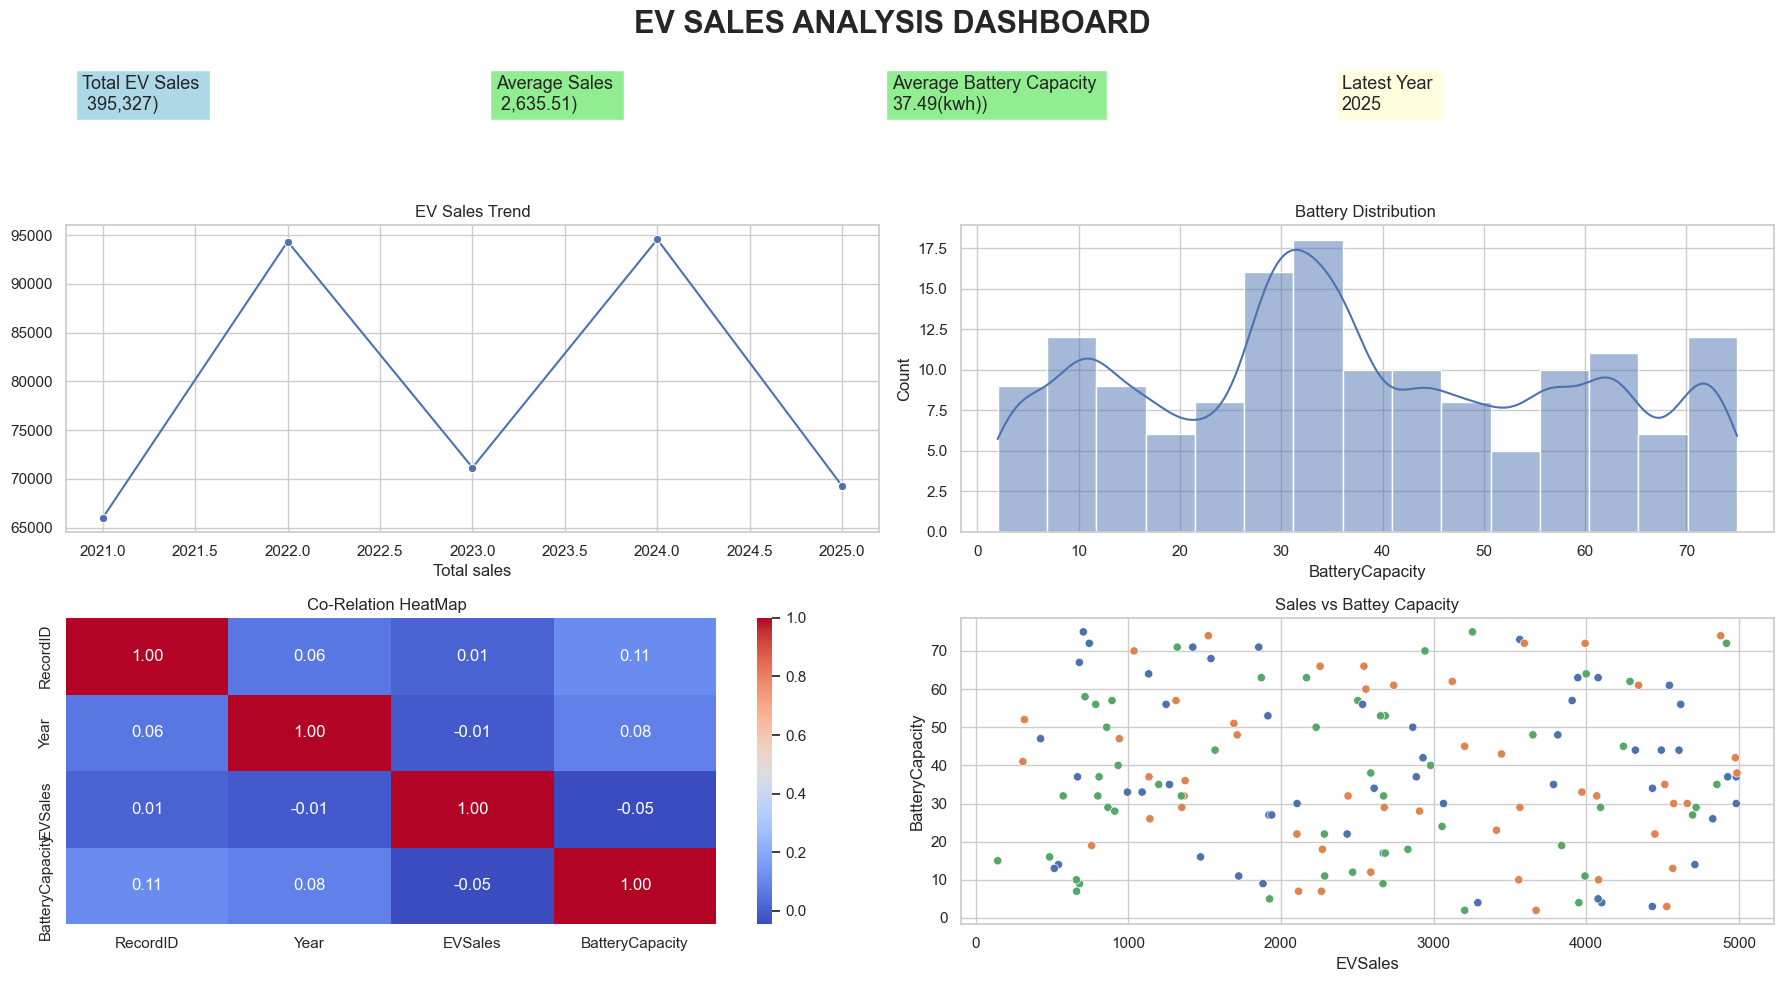

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig=plt.figure(figsize=(18,10))

#kpi cards
fig.suptitle("EV SALES ANALYSIS DASHBOARD",
            fontsize=22,
            fontweight="bold")
fig.text(0.05,0.88,
        f"Total EV Sales \n { ev['EVSales'].sum():,.0f})",
        fontsize=13,
        bbox=dict(facecolor='lightblue'))

fig.text(0.28,0.88,
         f"Average Sales \n {ev['EVSales'].mean():,.2f})",
         fontsize=13,
        bbox=dict(facecolor='lightgreen')) 

fig.text(0.50,0.88,
        f"Average Battery Capacity \n{ev['BatteryCapacity'].mean():,.2f}(kwh))",
        fontsize=13,
        bbox=dict(facecolor='lightgreen')) 
    
fig.text(0.75,0.88,
        f"Latest Year \n{ev['Year'].max():}",
        fontsize=13,
        bbox=dict(facecolor='lightyellow'))
# sales 
yearly_sales=ev.groupby("Year")["EVSales"].sum().reset_index()
yearly_sales

fig=plt.subplot(2,2,1)
yearly_sales=ev.groupby("Year")["EVSales"].sum()

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker='o')

plt.title("EV Sales Trend")
plt.xlabel("Total sales")
#battery distribution
plt.subplot(2,2,2)

sns.histplot(
    ev["BatteryCapacity"],
    kde=True,
    bins=15,
    kde_kws={'bw_adjust':0.35}
)
plt.title("Battery Distribution ")

  # corelation heat map
plt.subplot(2,2,3)
x=ev.select_dtypes(include=["number"])
matrix=x.corr()

sns.heatmap(
    matrix,
    annot=True,
    cmap='coolwarm',
    fmt=',.2f'
)
plt.title("Co-Relation HeatMap  ")

### plot4 Sales vs Battery Capacity
plt.subplot(2,2,4)
sns.scatterplot(data=ev,
               x="EVSales",
               y="BatteryCapacity",
               hue="VehicleType",
               legend=False),
plt.title("Sales vs Battey Capacity")

plt.tight_layout(rect=[0,0,1,0.85])

plt.show()
  

